## Pretrained model

In [1]:
from UViT_libs.uvit import UViT
import torch

attention mode is flash


In [8]:
embed_dim = 256
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
nnet = UViT(img_size=16,
       patch_size=2,
       in_chans=4,
       embed_dim=embed_dim,
       depth=13,
       num_heads=8,
       num_classes=-1,
       skip=True,
       conv=True,
       nz=25).to(device)

In [9]:
from torchinfo import summary

In [12]:
t = torch.randint(0, 4,
                    (1,), device=device)
latent_z1 = torch.randn(1, 25, device=device)
latent_z2 = torch.randn((1, 25), device=device)
x = torch.randn((1,4,16,16), device=device)

In [13]:
summary(nnet, input_data=[x, t, latent_z1])

Layer (type:depth-idx)                   Output Shape              Param #
UViT                                     [1, 4, 16, 16]            16,896
├─PatchEmbed: 1-1                        [1, 64, 256]              --
│    └─Conv2d: 2-1                       [1, 256, 8, 8]            4,352
├─Identity: 1-2                          [1, 256]                  --
├─Sequential: 1-3                        [1, 256]                  --
│    └─Linear: 2-2                       [1, 1024]                 26,624
│    └─ReLU: 2-3                         [1, 1024]                 --
│    └─Linear: 2-4                       [1, 1024]                 1,049,600
│    └─ReLU: 2-5                         [1, 1024]                 --
│    └─Linear: 2-6                       [1, 1024]                 1,049,600
│    └─ReLU: 2-7                         [1, 1024]                 --
│    └─Linear: 2-8                       [1, 256]                  262,400
│    └─ReLU: 2-9                         [1, 256]      

In [18]:
from score_sde.models.discriminator import Discriminator_small
import torch.nn as nn
netD = Discriminator_small(nc=2 * 4, ngf=64,
                    t_emb_dim=256,
                    act=nn.LeakyReLU(0.2), num_layers=3).to(device)

In [19]:
summary(netD, input_data=[x, t, x])

Layer (type:depth-idx)                   Output Shape              Param #
Discriminator_small                      [256, 1]                  --
├─TimestepEmbedding: 1-1                 [256, 256]                --
│    └─Sequential: 2-1                   [256, 256]                65,792
│    │    └─Linear: 3-1                  [256, 256]                65,792
├─DownConvBlock: 1-18                    --                        (recursive)
│    └─LeakyReLU: 2-2                    [256, 256]                --
├─TimestepEmbedding: 1-3                 --                        (recursive)
│    └─Sequential: 2-3                   --                        (recursive)
│    │    └─Linear: 3-2                  [256, 256]                65,792
├─DownConvBlock: 1-18                    --                        (recursive)
│    └─LeakyReLU: 2-4                    [256, 256]                --
├─Conv2d: 1-5                            [256, 128, 16, 16]        1,152
├─DownConvBlock: 1-6              

## CIFAR10

In [2]:
from ldm.util import instantiate_from_config
from omegaconf import OmegaConf
import torch

from score_sde.models.ncsnpp_generator_adagn import NCSNpp
import yaml
from ldm.util import instantiate_from_config

device = torch.device('cuda:1')
config_path = "/home/luan2/stable_diffusion/autoencoder/config/cifar10_16x16x4.yaml"
ckpt_path = "/home/luan2/stable_diffusion/autoencoder/weight/16x16x4_551.ckpt"
with open(config_path, 'r') as file:
    config = yaml.safe_load(file)

AutoEncoder = instantiate_from_config(config['model'])


checkpoint = torch.load(ckpt_path, map_location=device)
AutoEncoder.load_state_dict(checkpoint['state_dict'])
AutoEncoder.eval()
AutoEncoder.to(device)

making attention of type 'vanilla' with 256 in_channels
making attention of type 'vanilla' with 256 in_channels
making attention of type 'vanilla' with 256 in_channels
Working with z of shape (1, 4, 16, 16) = 1024 dimensions.
making attention of type 'vanilla' with 256 in_channels
making attention of type 'vanilla' with 256 in_channels
making attention of type 'vanilla' with 256 in_channels
making attention of type 'vanilla' with 256 in_channels
loaded pretrained LPIPS loss from taming/modules/autoencoder/lpips/vgg.pth


AutoencoderKL(
  (encoder): Encoder(
    (conv_in): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (down): ModuleList(
      (0): Module(
        (block): ModuleList(
          (0-1): 2 x ResnetBlock(
            (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
            (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (norm2): GroupNorm(32, 128, eps=1e-06, affine=True)
            (dropout): Dropout(p=0.2, inplace=False)
            (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          )
        )
        (attn): ModuleList()
        (downsample): Downsample(
          (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2))
        )
      )
      (1): Module(
        (block): ModuleList(
          (0): ResnetBlock(
            (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
            (conv1): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (no

In [12]:
t = torch.randint(0, 4,
                    (1,), device=device)
latent_z1 = torch.randn(1, 25, device=device)
x = torch.randn((1,4,16,16), device=device)

from torchinfo import summary
summary(AutoEncoder.decoder, input_size=(1, 4, 16, 16))

Layer (type:depth-idx)                        Output Shape              Param #
Decoder                                       [1, 3, 32, 32]            --
├─Conv2d: 1-1                                 [1, 256, 16, 16]          9,472
├─Module: 1-2                                 --                        --
│    └─ResnetBlock: 2-1                       [1, 256, 16, 16]          --
│    │    └─GroupNorm: 3-1                    [1, 256, 16, 16]          512
│    │    └─Conv2d: 3-2                       [1, 256, 16, 16]          590,080
│    │    └─GroupNorm: 3-3                    [1, 256, 16, 16]          512
│    │    └─Dropout: 3-4                      [1, 256, 16, 16]          --
│    │    └─Conv2d: 3-5                       [1, 256, 16, 16]          590,080
│    └─AttnBlock: 2-2                         [1, 256, 16, 16]          --
│    │    └─GroupNorm: 3-6                    [1, 256, 16, 16]          512
│    │    └─Conv2d: 3-7                       [1, 256, 16, 16]          65,792


## LSUN

In [1]:
from ldm.util import instantiate_from_config
from omegaconf import OmegaConf
import torch

from score_sde.models.ncsnpp_generator_adagn import NCSNpp
import yaml
from ldm.util import instantiate_from_config

device = torch.device('cuda:0')
config_path = "/home/luan2/stable_diffusion/autoencoder/config/CELEBA_config.yaml"
ckpt_path = "/home/luan2/stable_diffusion/autoencoder/weight/CELEBA_weight.ckpt"

def load_model_from_config(config_path, ckpt):
    print(f"Loading model from {ckpt}")
    config = OmegaConf.load(config_path)
    pl_sd = torch.load(ckpt, map_location="cpu")
    #global_step = pl_sd["global_step"]
    sd = pl_sd["state_dict"]
    model = instantiate_from_config(config.model)
    m, u = model.load_state_dict(sd, strict=False)
    model = model.first_stage_model
    model.cuda()
    model.eval()
    del m
    del u
    del pl_sd
    return model

AutoEncoder = load_model_from_config(config_path, ckpt_path)

Loading model from /home/luan2/stable_diffusion/autoencoder/weight/CELEBA_weight.ckpt
LatentDiffusion: Running in eps-prediction mode
DiffusionWrapper has 274.06 M params.
Keeping EMAs of 370.
making attention of type 'vanilla' with 512 in_channels
Working with z of shape (1, 3, 64, 64) = 12288 dimensions.
making attention of type 'vanilla' with 512 in_channels
Training LatentDiffusion as an unconditional model.


In [6]:
from torchinfo import summary
summary(AutoEncoder.decoder, input_size=(1, 3, 64, 64))

Layer (type:depth-idx)                        Output Shape              Param #
Decoder                                       [1, 3, 256, 256]          --
├─Conv2d: 1-1                                 [1, 512, 64, 64]          (14,336)
├─Module: 1-2                                 --                        --
│    └─ResnetBlock: 2-1                       [1, 512, 64, 64]          --
│    │    └─GroupNorm: 3-1                    [1, 512, 64, 64]          (1,024)
│    │    └─Conv2d: 3-2                       [1, 512, 64, 64]          (2,359,808)
│    │    └─GroupNorm: 3-3                    [1, 512, 64, 64]          (1,024)
│    │    └─Dropout: 3-4                      [1, 512, 64, 64]          --
│    │    └─Conv2d: 3-5                       [1, 512, 64, 64]          (2,359,808)
│    └─AttnBlock: 2-2                         [1, 512, 64, 64]          --
│    │    └─GroupNorm: 3-6                    [1, 512, 64, 64]          (1,024)
│    │    └─Conv2d: 3-7                       [1, 512, 6

In [2]:
from fvcore.nn import FlopCountAnalysis
import numpy as np
x = torch.randn((1,3,64,64), device=device)
flop = FlopCountAnalysis(AutoEncoder.decoder, x)


In [3]:
flop.total()

Unsupported operator aten::sigmoid encountered 23 time(s)
Unsupported operator aten::mul encountered 27 time(s)
Unsupported operator aten::add encountered 12 time(s)
Unsupported operator aten::softmax encountered 1 time(s)
Unsupported operator aten::tanh encountered 1 time(s)


335913418752

In [4]:
from fvcore.nn import flop_count_table
print(flop_count_table(flop))

| module                 | #parameters or shape   | #flops     |
|:-----------------------|:-----------------------|:-----------|
| model                  | 32.961M                | 0.336T     |
|  conv_in               |  14.336K               |  56.623M   |
|   conv_in.weight       |   (512, 3, 3, 3)       |            |
|   conv_in.bias         |   (512,)               |            |
|  mid                   |  10.495M               |  60.182G   |
|   mid.block_1          |   4.722M               |   19.348G  |
|    mid.block_1.norm1   |    1.024K              |    10.486M |
|    mid.block_1.conv1   |    2.36M               |    9.664G  |
|    mid.block_1.norm2   |    1.024K              |    10.486M |
|    mid.block_1.conv2   |    2.36M               |    9.664G  |
|   mid.attn_1           |   1.052M               |   21.485G  |
|    mid.attn_1.norm     |    1.024K              |    10.486M |
|    mid.attn_1.q        |    0.263M              |    1.074G  |
|    mid.attn_1.k        

## Plot

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

path = "/home/luan2/stable_diffusion/saved_info/csv/chato_2.csv"
path_2 = "/home/luan2/stable_diffusion/saved_info/csv/rotom.csv"
path_3 = "/home/luan2/stable_diffusion/saved_info/csv/greverler.csv"
path_4 = "/home/luan2/stable_diffusion/saved_info/cifar10/UViT_Layer5_Emb256_Head8_nz25_mlpnoise_noConvSkip/fidnew.csv"

data = pd.read_csv(path)
data_2 = pd.read_csv(path_2)
data_3 = pd.read_csv(path_3)
data_4 = pd.read_csv(path_4)

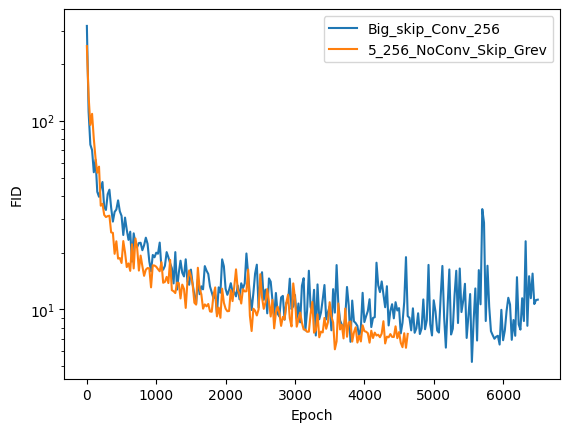

In [4]:
plt.plot(data["Epoch"], data["FID"], label='Big_skip_Conv_256')
#plt.plot(data_2["Epoch"], data_2["FID"], label='5_256_Noskip_Noconv')
plt.plot(data_3["Epoch"], data_3["FID"], label='5_256_NoConv_Skip_Grev')
#plt.plot(data_4["Epoch"], data_4["FID"], label='5_256_NOConv_NOSkip_MLPNoi')
plt.xlabel("Epoch")
plt.ylabel("FID")
plt.legend()
plt.yscale("log")

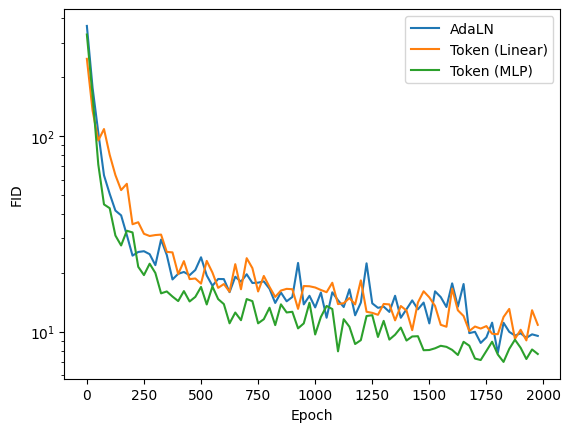

In [18]:
plt.plot(data_2["Epoch"][:80], data_2["FID"][:80], label='AdaLN')
plt.plot(data_3["Epoch"][:80], data_3["FID"][:80], label='Token (Linear)')
plt.plot(data_4["Epoch"][:80], data_4["FID"][:80], label='Token (MLP)')
plt.xlabel("Epoch")
plt.ylabel("FID")
plt.legend()
plt.yscale("log")